# Toy Walkthrough: Silhouette Score for `all_heads` vs `cardio_only`

This notebook is a pedagogical toy example of the latent-manifold plot used in `run/train_sep_vae.py`.

It follows the same high-level pipeline:

1. start from fake encoder mean maps `mu_common(x)` and `mu_cardio(x)`
2. spatially average them to get one vector per image
3. build `all_heads = [z_common, z_cardio]` and `cardio_only = z_cardio`
4. run PCA to 2D
5. compute the silhouette score on the 2D points
6. manually compute the silhouette score for one example point

The numbers in this notebook are toy numbers. The goal is to make the process easy to see, not to reproduce an exact training run.

## 1. What the real code does

For each image, the encoder outputs mean maps:

$$
\mu_{\text{common}}(x), \qquad \mu_{\text{cardio}}(x)
$$

The plot code then spatially averages those maps:

$$
z_{\text{common}} = \operatorname{mean}_{h,w}(\mu_{\text{common}}),
\qquad
z_{\text{cardio}} = \operatorname{mean}_{h,w}(\mu_{\text{cardio}})
$$

Then it builds two feature sets:

$$
\text{all_heads} = [z_{\text{common}}, z_{\text{cardio}}],
\qquad
\text{cardio_only} = z_{\text{cardio}}
$$

Then it projects those vectors to 2D with PCA and computes the silhouette score on the resulting 2D points.

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

plt.style.use('seaborn-v0_8-whitegrid')
np.set_printoptions(precision=3, suppress=True)

## 2. Tiny example: from encoder mean maps to pooled vectors

Below we make one fake **normal** image and one fake **cardiomegaly** image.
Each image has a small `2 x 2 x C` mean map for the common head and the cardio head.

This is only to show where the vectors come from before PCA.

In [3]:
mu_common_normal = np.array([
    [[0.9, 1.1], [1.0, 0.8]],
    [[1.2, 0.7], [0.8, 1.0]],
])

mu_cardio_normal = np.array([
    [[0.05, -0.02], [0.01, 0.00]],
    [[-0.01, 0.02], [0.03, -0.02]],
])

mu_common_cardio = np.array([
    [[1.0, 0.9], [1.1, 0.8]],
    [[0.9, 1.2], [1.0, 0.7]],
])

mu_cardio_cardio = np.array([
    [[1.0, 0.8], [0.9, 1.1]],
    [[1.2, 0.7], [0.8, 0.9]],
])

def spatial_mean(mu_map):
    return mu_map.mean(axis=(0, 1))

z_common_normal = spatial_mean(mu_common_normal)
z_cardio_normal = spatial_mean(mu_cardio_normal)
z_common_cardio = spatial_mean(mu_common_cardio)
z_cardio_cardio = spatial_mean(mu_cardio_cardio)

print('Normal image')
print('  z_common    =', z_common_normal)
print('  z_cardio    =', z_cardio_normal)
print('  all_heads   =', np.concatenate([z_common_normal, z_cardio_normal]))
print()
print('Cardio image')
print('  z_common    =', z_common_cardio)
print('  z_cardio    =', z_cardio_cardio)
print('  all_heads   =', np.concatenate([z_common_cardio, z_cardio_cardio]))

Normal image
  z_common    = [0.975 0.9  ]
  z_cardio    = [ 0.02  -0.005]
  all_heads   = [ 0.975  0.9    0.02  -0.005]

Cardio image
  z_common    = [1.  0.9]
  z_cardio    = [0.975 0.875]
  all_heads   = [1.    0.9   0.975 0.875]


## 3. Make a toy batch of pooled latent vectors

Now we simulate many images.

- The **common** head has large shared variation. This acts like anatomy / acquisition nuisance variation.
- The **cardio** head has cleaner class-specific variation.

This is why the `all_heads` plot will usually have a lower silhouette score than `cardio_only`: the common head adds within-class spread.

In [4]:
rng = np.random.default_rng(7)
n_per_class = 120

# Shared / nuisance variation: broad and only weakly class-specific.
common_normal = rng.normal(
    loc=[0.0, 0.3, -0.2, 0.1],
    scale=[1.5, 1.2, 1.0, 1.3],
    size=(n_per_class, 4),
)
common_cardio = rng.normal(
    loc=[0.1, 0.0, -0.1, 0.2],
    scale=[1.5, 1.2, 1.0, 1.3],
    size=(n_per_class, 4),
)

# Disease variation: cleaner class separation.
cardio_normal = rng.normal(
    loc=[0.9, 0.7],
    scale=[0.35, 0.35],
    size=(n_per_class, 2),
)
cardio_cardio = rng.normal(
    loc=[-0.9, -0.7],
    scale=[0.45, 0.45],
    size=(n_per_class, 2),
)

labels = np.array([0] * n_per_class + [1] * n_per_class)
label_names = {0: 'Normal', 1: 'Cardiomegaly'}

all_heads_features = np.vstack([
    np.hstack([common_normal, cardio_normal]),
    np.hstack([common_cardio, cardio_cardio]),
])

cardio_only_features = np.vstack([
    cardio_normal,
    cardio_cardio,
])

all_heads_2d = PCA(n_components=2, random_state=42).fit_transform(all_heads_features)
cardio_only_2d = PCA(n_components=2, random_state=42).fit_transform(cardio_only_features)

sil_all = silhouette_score(all_heads_2d, labels)
sil_cardio = silhouette_score(cardio_only_2d, labels)

print(f'all_heads silhouette    = {sil_all:.3f}')
print(f'cardio_only silhouette  = {sil_cardio:.3f}')

all_heads silhouette    = 0.085
cardio_only silhouette  = 0.666


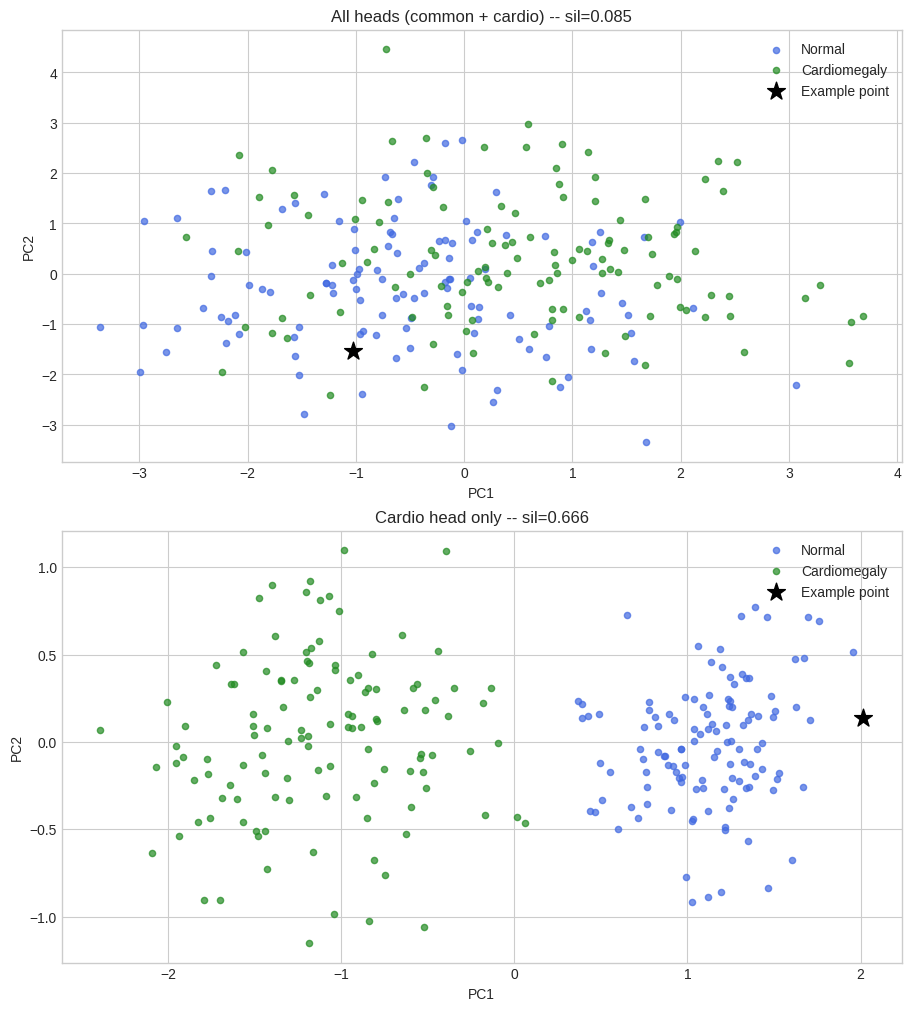

In [5]:
def plot_panel(ax, points_2d, labels, title, highlight_idx=0):
    colors = {0: 'royalblue', 1: 'forestgreen'}
    names = {0: 'Normal', 1: 'Cardiomegaly'}
    for cls in [0, 1]:
        mask = labels == cls
        ax.scatter(
            points_2d[mask, 0],
            points_2d[mask, 1],
            s=20,
            alpha=0.7,
            color=colors[cls],
            label=names[cls],
        )
    ax.scatter(
        points_2d[highlight_idx, 0],
        points_2d[highlight_idx, 1],
        marker='*',
        s=180,
        color='black',
        label='Example point',
    )
    ax.set_title(title)
    ax.set_xlabel('PC1')
    ax.set_ylabel('PC2')
    ax.legend(loc='best')

fig, axes = plt.subplots(2, 1, figsize=(9, 10), constrained_layout=True)

plot_panel(
    axes[0],
    all_heads_2d,
    labels,
    f'All heads (common + cardio) -- sil={sil_all:.3f}',
    highlight_idx=0,
)

plot_panel(
    axes[1],
    cardio_only_2d,
    labels,
    f'Cardio head only -- sil={sil_cardio:.3f}',
    highlight_idx=0,
)

plt.show()

## 4. Manually compute the silhouette score for one example point

For a point $i$:

$$
a(i) = \text{average distance to points in the same class}
$$

$$
b(i) = \text{average distance to points in the other class}
$$

$$
\mathrm{sil}(i) = \frac{b(i) - a(i)}{\max(a(i), b(i))}
$$

We compute that below for the black star point in each subplot.

In [ ]:
def silhouette_for_point(points_2d, labels, idx):
    point = points_2d[idx]
    same_mask = labels == labels[idx]
    other_mask = labels != labels[idx]

    same_points = points_2d[same_mask]
    other_points = points_2d[other_mask]

    same_dists = np.linalg.norm(same_points - point, axis=1)
    same_dists = same_dists[same_dists > 0]
    other_dists = np.linalg.norm(other_points - point, axis=1)

    a_i = same_dists.mean()
    b_i = other_dists.mean()
    sil_i = (b_i - a_i) / max(a_i, b_i)
    return a_i, b_i, sil_i

for name, points in [('all_heads', all_heads_2d), ('cardio_only', cardio_only_2d)]:
    a_i, b_i, sil_i = silhouette_for_point(points, labels, idx=0)
    print(name)
    print(f'  class of example point = {label_names[labels[0]]}')
    print(f'  a(i) = mean distance to same class  = {a_i:.3f}')
    print(f'  b(i) = mean distance to other class = {b_i:.3f}')
    print(f'  sil(i) = (b-a)/max(a,b)            = {sil_i:.3f}')
    print()

## 5. Interpretation

If `cardio_only` gets the higher silhouette score, that means the disease head alone is more class-separating than the concatenated latent.

That usually happens because:
- `z_cardio` carries class-relevant disease information
- `z_common` carries shared anatomy / acquisition variation, which increases within-class spread
- PCA on `all_heads` can devote variance to shared structure, not only to class separation

So a higher silhouette score for `cardio_only` is usually supportive of the intended decomposition:

$$
z_{\text{common}} = \text{shared structure},
\qquad
z_{\text{cardio}} = \text{disease-specific residual}.
$$

The important caveat is the same as in the real training plots: this score is computed on the **2D PCA projection**, so it is a useful diagnostic rather than a proof about the full latent space.